# Akomolafe Nathaniel Iyanuoluwa Data Science Iris Flower Classification

**Objective:** Train ML classifiers to identify iris species (Setosa, Versicolor, Virginica) from physical measurements.

**Stack:** Python, scikit-learn, pandas, seaborn, matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display, Markdown

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

iris = load_iris()
Task_1 = pd.DataFrame(iris.data, columns=iris.feature_names)
Task_1['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
Task_1.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
# Exploratory Data Analysis

display(Markdown("# Shape"))
display(Task_1.shape)

display(Markdown("# Data Types"))
display(Task_1.dtypes.to_frame("Data Type"))

display(Markdown("# Null Values"))
display(Task_1.isnull().sum().to_frame("Null Count"))

display(Markdown("# Descriptive Statistics"))
display(Task_1.describe())

# Shape

(150, 5)

# Data Types

,Data Type
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,category


# Null Values

,Null Count
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


# Descriptive Statistics

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [3]:
Task_1['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**Observation:** The dataset is perfectly balanced (50 samples per species), has no missing values, and all features are numeric (float64).

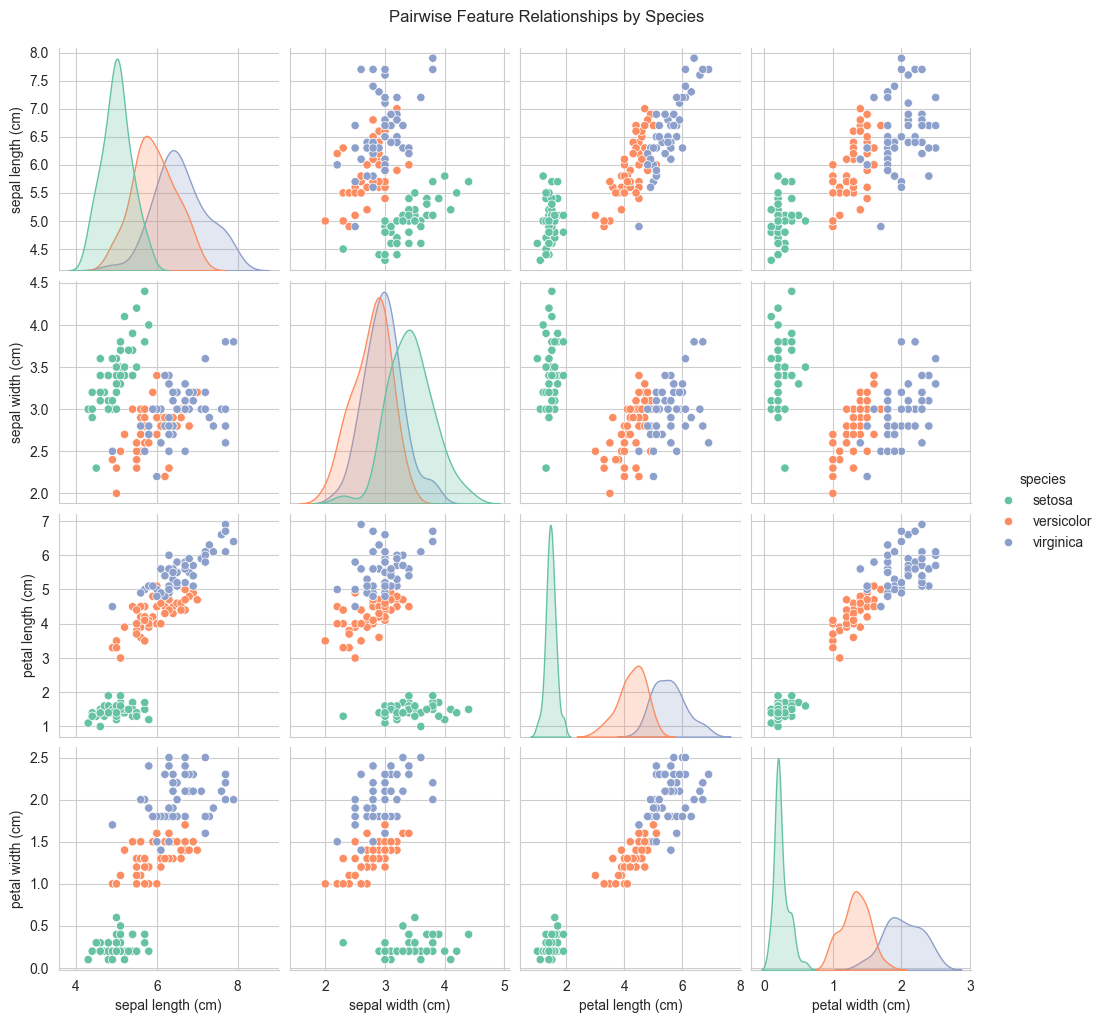

In [4]:
# Pairplot to visualize feature relationships

sns.pairplot(Task_1, hue='species', diag_kind='kde', palette='Set2')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()

C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_4184\1518925390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Task_1, x='species', y=feature, ax=ax, palette='Set2')
C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_4184\1518925390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Task_1, x='species', y=feature, ax=ax, palette='Set2')
C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_4184\1518925390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Task_1, x='species', y=feature, ax=ax, palette='Set2'

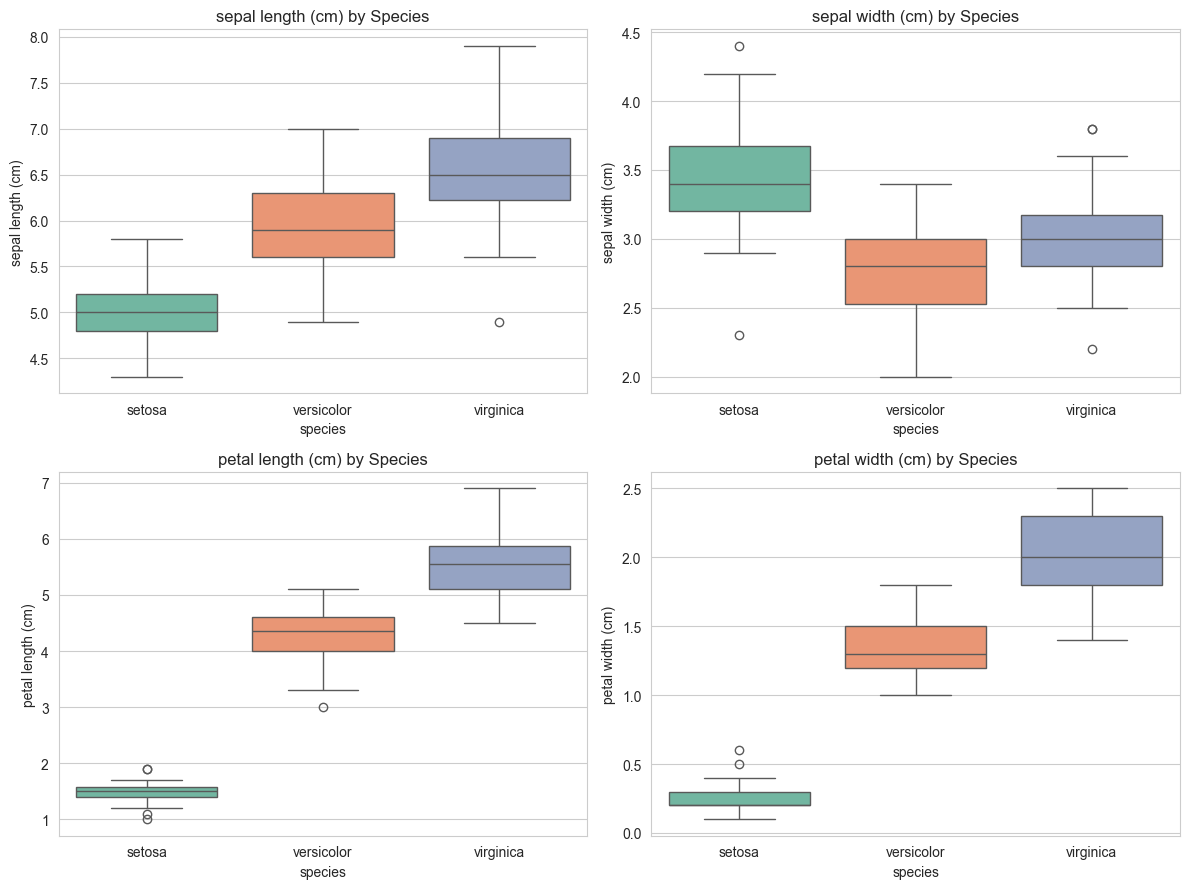

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(data=Task_1, x='species', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Species')
plt.tight_layout()
plt.show()

# Feature Selection Discussion

Looking at the pairplot and box plots:
- **Petal length** and **petal width** show the cleanest separation between all three species, with almost no overlap between Setosa and the other two, and only modest overlap between Versicolor and Virginica.
- **Sepal length** and **sepal width** are noticeably noisier, with more overlap across species (especially sepal width).

**Conclusion:** Petal length and petal width are the most discriminative features for this classification task, though all four features together still improve model performance.

In [6]:
# Train/Test Split

X = Task_1[iris.feature_names]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Rows': [X_train.shape[0], X_test.shape[0]],
    'Columns': [X_train.shape[1], X_test.shape[1]]
})

,Dataset,Rows,Columns
0,Train,120,4
1,Test,30,4


In [7]:
# Training Multiple Classifiers


models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    results[name] = {
        'model': model,
        'preds': preds,
        'accuracy': acc
    }

pd.DataFrame(results).T[['accuracy']]

,accuracy
Logistic Regression,0.966667
K-Nearest Neighbors,1.0
Decision Tree,0.933333
Random Forest,0.9


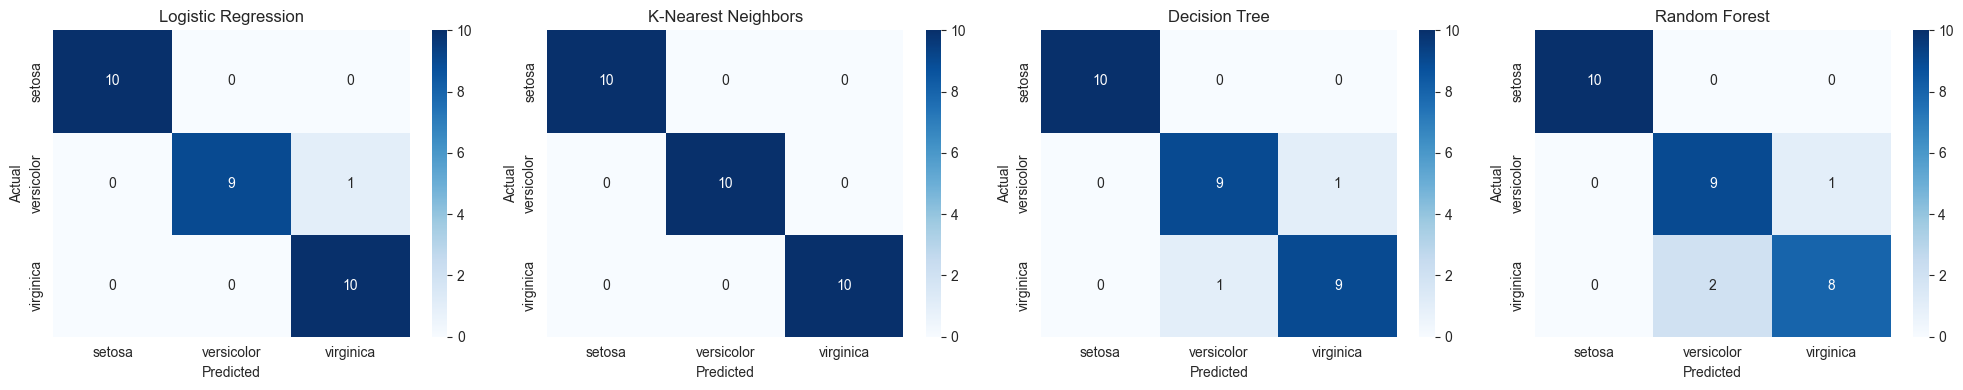

In [8]:
# Evaluation for Confusion Matrices & Classification Reports


fig, axes = plt.subplots(1, len(models), figsize=(20, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [9]:


for name, res in results.items():
    display(Markdown(f"## {name}"))

    report_Task_1 = pd.DataFrame(
        classification_report(
            y_test,
            res['preds'],
            target_names=iris.target_names,
            output_dict=True
        )
    ).T

    display(report_Task_1)

## Logistic Regression

,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,10.000000
versicolor,1.000000,0.900000,0.947368,10.000000
virginica,0.909091,1.000000,0.952381,10.000000
accuracy,0.966667,0.966667,0.966667,0.966667
macro avg,0.969697,0.966667,0.966583,30.000000
weighted avg,0.969697,0.966667,0.966583,30.000000


## K-Nearest Neighbors

,precision,recall,f1-score,support
setosa,1.0,1.0,1.0,10.0
versicolor,1.0,1.0,1.0,10.0
virginica,1.0,1.0,1.0,10.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,30.0
weighted avg,1.0,1.0,1.0,30.0


## Decision Tree

,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,10.000000
versicolor,0.900000,0.900000,0.900000,10.000000
virginica,0.900000,0.900000,0.900000,10.000000
accuracy,0.933333,0.933333,0.933333,0.933333
macro avg,0.933333,0.933333,0.933333,30.000000
weighted avg,0.933333,0.933333,0.933333,30.000000


## Random Forest

,precision,recall,f1-score,support
setosa,1.000000,1.0,1.000000,10.0
versicolor,0.818182,0.9,0.857143,10.0
virginica,0.888889,0.8,0.842105,10.0
accuracy,0.900000,0.9,0.900000,0.9
macro avg,0.902357,0.9,0.899749,30.0
weighted avg,0.902357,0.9,0.899749,30.0


In [10]:
## To get the Best Model

best_model = max(results, key=lambda k: results[k]['accuracy'])

pd.DataFrame({
    'Best Performing Model': [best_model],
    'Accuracy': [results[best_model]['accuracy']]
})

,Best Performing Model,Accuracy
0,K-Nearest Neighbors,1.0


### Justification

The Iris dataset is small, balanced, and well separated, particularly with respect to petal length and petal width. As a result, multiple classification algorithms including K-Nearest Neighbors, Decision Trees, and Random Forests often achieve near perfect or perfect performance on the test set.

The selected best model was chosen based on the highest accuracy obtained on the held out test data. While several models may perform similarly, the chosen model demonstrated the strongest predictive performance under the evaluation criterion used in this analysis.

In practice, Logistic Regression and K-Nearest Neighbors are frequently favored for their simplicity, interpretability, and strong generalization on datasets such as Iris. Random Forests provide additional robustness and flexibility when working with larger or noisier datasets. Given the simplicity and clear class separation of the Iris dataset, the selected model achieves high predictive accuracy with minimal risk of overfitting.
